# 강남구 물류 최적화 시뮬레이션

## 프로젝트 개요
이 노트북은 강남구의 배송 데이터를 활용하여 최적의 물류 거점과 차량 운영 방안을 도출합니다.

### 주요 단계
1. 데이터 로드 및 무게 중심 계산
2. 도로망 데이터 로드 및 거점 후보 탐색
3. VRP(차량 경로 문제) 시뮬레이션 (용량 제약 포함)
4. 결과 분석 및 시각화

---

## 1. 라이브러리 임포트 및 초기 설정

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import sys
from IPython.display import clear_output

# 도로망 분석
import osmnx as ox
import networkx as nx
from scipy.spatial import cKDTree

# 최적화
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("✓ 모든 라이브러리 로드 완료")

✓ 모든 라이브러리 로드 완료


## 2. 데이터 로드 및 무게 중심 계산

강남구의 배송지 데이터를 로드하고, 수요의 무게 중심(Center of Gravity)을 계산합니다.

In [2]:
# 파일 경로 설정
file_path = '최종_배송목록_20231201_강남구.csv'

# CSV 파일 안전 로드 함수
def read_csv_safe(p):
    for enc in ["utf-8-sig", "euc-kr", "cp949"]:
        try:
            df = pd.read_csv(p, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except UnicodeDecodeError:
            continue
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    return df

# 데이터 로드
df_deliveries = read_csv_safe(file_path)

# 데이터 확인
print(f"총 배송지 수: {len(df_deliveries):,}개")
print(f"\n컬럼 목록: {df_deliveries.columns.tolist()}")
print(f"\n데이터 샘플:")
df_deliveries.head()

총 배송지 수: 84,818개

컬럼 목록: ['배송지_ID', '위도', '경도', '배송지_유형', '배송지명']

데이터 샘플:


,배송지_ID,위도,경도,배송지_유형,배송지명
0,1,37.483894,127.055990,주거,개포우성3차
1,2,37.480287,127.057848,주거,디에이치퍼스티어아이파크
2,3,37.478480,127.054031,주거,개포래미안포레스트
3,4,37.484704,127.087769,주거,수서까치마을
4,5,37.481852,127.081046,주거,상록수아파트


In [3]:
# 위도/경도 데이터 확인 및 변환
if '위도' not in df_deliveries.columns or '경도' not in df_deliveries.columns:
    raise KeyError("필수 칼럼(위도, 경도)이 최종 배송 목록에 없습니다.")

df_deliveries['위도'] = pd.to_numeric(df_deliveries['위도'], errors='coerce')
df_deliveries['경도'] = pd.to_numeric(df_deliveries['경도'], errors='coerce')

# 유효한 좌표만 사용
df_valid_coords = df_deliveries.dropna(subset=['위도', '경도'])

# 무게 중심 계산
center_lat = df_valid_coords['위도'].mean()
center_lon = df_valid_coords['경도'].mean()

print(f"\n강남구 배송 수요의 이상적인 무게 중심 (Center of Gravity):")
print(f"  - 위도: {center_lat:.6f}")
print(f"  - 경도: {center_lon:.6f}")
print(f"  - 유효 좌표 수: {len(df_valid_coords):,}개")


강남구 배송 수요의 이상적인 무게 중심 (Center of Gravity):
  - 위도: 37.498098
  - 경도: 127.057827
  - 유효 좌표 수: 84,818개


## 3. 도로망 데이터 로드 및 거점 후보 탐색

OSMnx를 사용하여 강남구의 실제 도로망 데이터를 로드하고, 무게 중심에서 가장 가까운 교차로 노드를 거점 후보로 선정합니다.

In [4]:
# 도로망 데이터 로드
place_name = 'Gangnam-gu, Seoul, South Korea'
graph_path = 'gangnam_drive_network.graphml'

try:
    G = ox.load_graphml(graph_path)
    print(f"✓ '{graph_path}' 파일에서 도로망 데이터를 불러왔습니다.")
except FileNotFoundError:
    print(f"'{graph_path}' 파일이 없어 새로 다운로드합니다...")
    G = ox.graph_from_place(place_name, network_type='drive')
    ox.save_graphml(G, graph_path)
    print(f"✓ 도로망 데이터를 '{graph_path}'에 저장했습니다.")

print(f"\n도로망 정보:")
print(f"  - 노드(교차로) 수: {len(G.nodes):,}개")
print(f"  - 엣지(도로) 수: {len(G.edges):,}개")

✓ 'gangnam_drive_network.graphml' 파일에서 도로망 데이터를 불러왔습니다.

도로망 정보:
  - 노드(교차로) 수: 3,122개
  - 엣지(도로) 수: 8,390개


In [5]:
# 무게 중심에서 가장 가까운 교차로 노드 찾기
num_candidates = 3

# cKDTree를 사용하여 k개의 가장 가까운 노드 찾기
nodes_coords = np.array([[G.nodes[node]['x'], G.nodes[node]['y']] for node in G.nodes()])
tree = cKDTree(nodes_coords)
distances, indices = tree.query([center_lon, center_lat], k=num_candidates)
depot_candidates = [list(G.nodes())[i] for i in indices]

print(f"\n이상적 위치에서 가장 가까운 현실적 거점 후보 노드 {num_candidates}개:")
print(f"노드 ID: {depot_candidates}\n")

# 후보 노드들의 좌표 확인
candidate_nodes_data = G.nodes(data=True)
for i, node_id in enumerate(depot_candidates, 1):
    node_info = candidate_nodes_data[node_id]
    dist_km = distances[i-1] * 111  # 대략적인 km 변환
    print(f"{i}. 노드 ID {node_id}:")
    print(f"   위도: {node_info['y']:.6f}, 경도: {node_info['x']:.6f}")
    print(f"   무게중심으로부터 거리: 약 {dist_km:.2f}km\n")


이상적 위치에서 가장 가까운 현실적 거점 후보 노드 3개:
노드 ID: [4183907894, 2048462945, 355063396]

1. 노드 ID 4183907894:
   위도: 37.497964, 경도: 127.058019
   무게중심으로부터 거리: 약 0.03km

2. 노드 ID 2048462945:
   위도: 37.497525, 경도: 127.058620
   무게중심으로부터 거리: 약 0.11km

3. 노드 ID 355063396:
   위도: 37.498237, 경도: 127.058878
   무게중심으로부터 거리: 약 0.12km



### 도로망 시각화 (선택 사항)

강남구 도로망의 구조를 확인해봅니다. 전체 네트워크가 복잡하므로 일부 영역만 표시합니다.

✓ 도로망 시각화 저장 완료: 강남구_도로망_구조.png


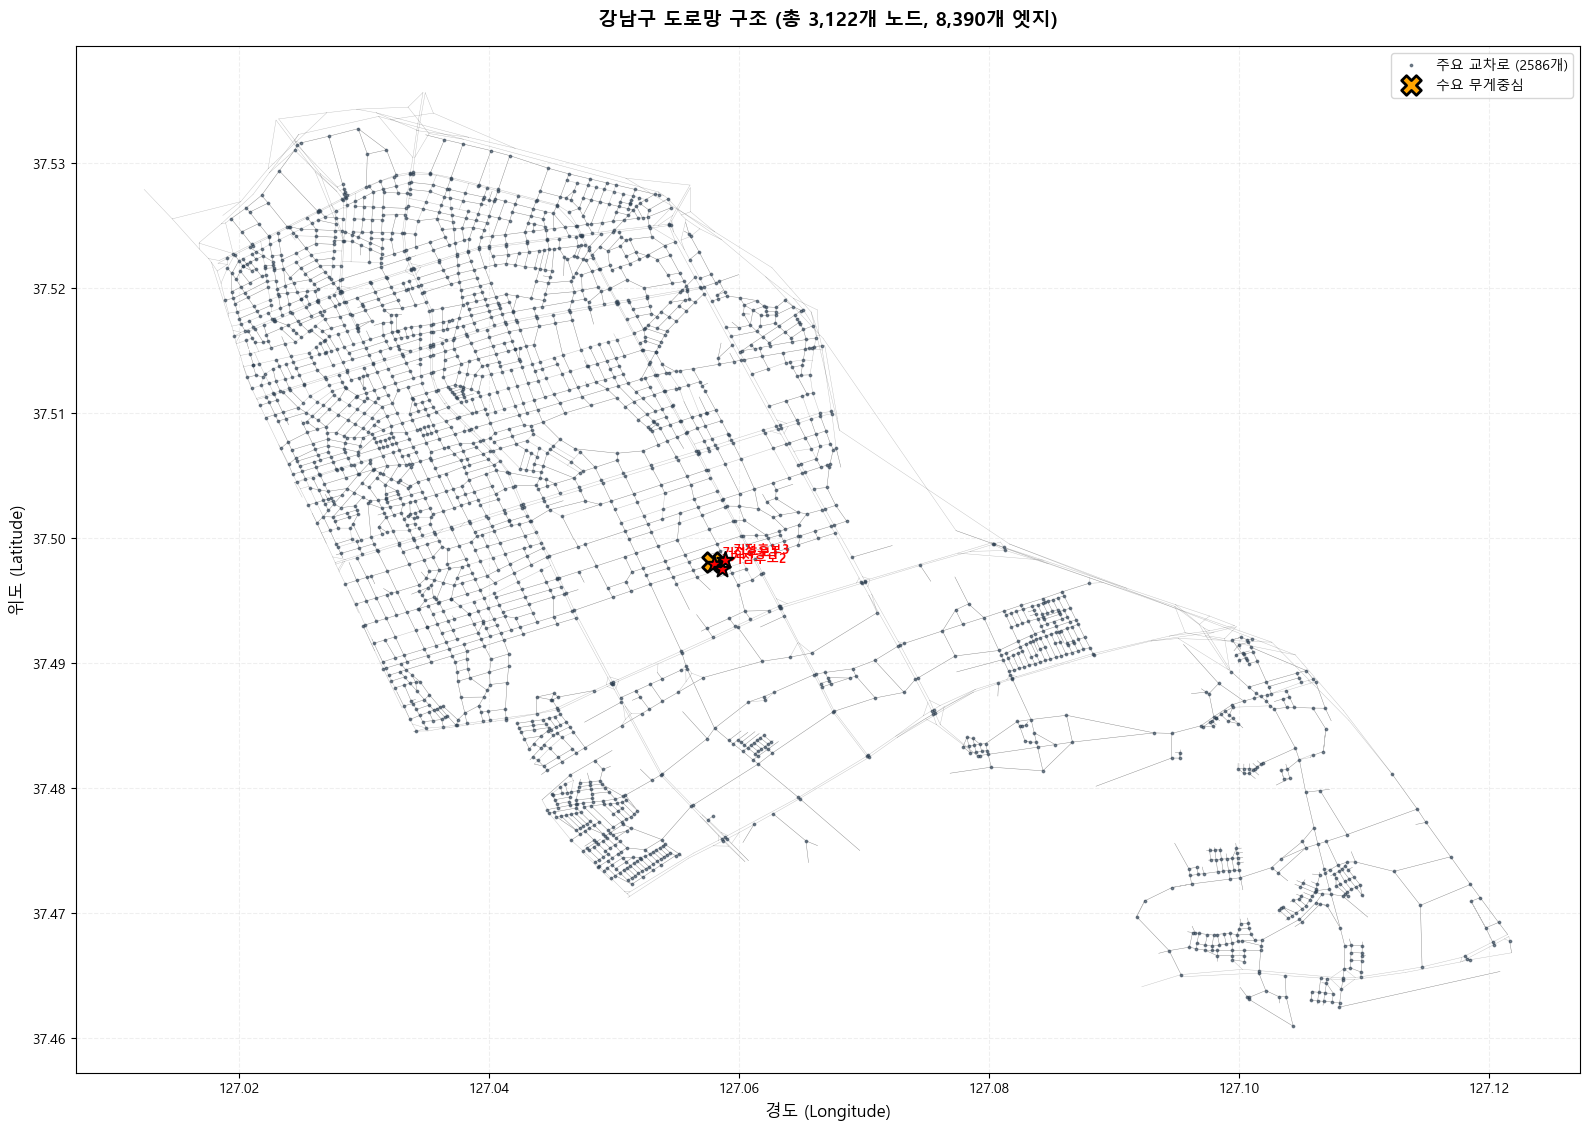


도로망 통계:
  - 전체 노드(교차로): 3,122개
  - 전체 엣지(도로): 8,390개
  - 주요 교차로 (degree≥4): 2,586개
  - 평균 연결도: 5.37


In [6]:
# 도로망 시각화 (전체 또는 일부)
fig, ax = plt.subplots(figsize=(16, 12))

# 방법 1: OSMnx의 plot_graph 사용 (간단하지만 느림)
# ox.plot_graph(G, ax=ax, node_size=1, edge_linewidth=0.5, bgcolor='white')

# 방법 2: NetworkX로 직접 그리기 (빠르고 커스터마이즈 가능)
# 노드 위치 추출
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# 모든 엣지 그리기 (도로)
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

ax.plot(edge_x, edge_y, 'gray', linewidth=0.3, alpha=0.5, zorder=1)

# 주요 교차로만 표시 (degree가 높은 노드)
node_degrees = dict(G.degree())
major_nodes = [node for node, degree in node_degrees.items() if degree >= 4]
major_x = [pos[node][0] for node in major_nodes]
major_y = [pos[node][1] for node in major_nodes]
ax.scatter(major_x, major_y, c='#2c3e50', s=3, alpha=0.6, zorder=2, label=f'주요 교차로 ({len(major_nodes)}개)')

# 거점 후보 노드 강조 표시
for i, depot_id in enumerate(depot_candidates):
    depot_x, depot_y = pos[depot_id]
    ax.scatter(depot_x, depot_y, c='red', s=150, marker='*', 
              edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(f'거점후보{i+1}', (depot_x, depot_y), 
               xytext=(5, 5), textcoords='offset points', 
               fontsize=9, fontweight='bold', color='red')

# 무게 중심 표시
ax.scatter(center_lon, center_lat, c='orange', s=200, marker='X', 
          edgecolors='black', linewidth=2, zorder=4, label='수요 무게중심')

# 그래프 설정
ax.set_xlabel('경도 (Longitude)', fontsize=12)
ax.set_ylabel('위도 (Latitude)', fontsize=12)
ax.set_title(f'강남구 도로망 구조 (총 {len(G.nodes):,}개 노드, {len(G.edges):,}개 엣지)', 
            fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('강남구_도로망_구조.png', dpi=200, bbox_inches='tight')
print("✓ 도로망 시각화 저장 완료: 강남구_도로망_구조.png")
plt.show()

print(f"\n도로망 통계:")
print(f"  - 전체 노드(교차로): {len(G.nodes):,}개")
print(f"  - 전체 엣지(도로): {len(G.edges):,}개")
print(f"  - 주요 교차로 (degree≥4): {len(major_nodes):,}개")
print(f"  - 평균 연결도: {sum(node_degrees.values())/len(node_degrees):.2f}")

## 4. 시뮬레이션 파라미터 설정 및 배송지 샘플링

In [7]:
# 차량 정보 설정
vehicles = {
    'diesel_1t': {
        'name': '1톤 디젤 트럭',
        'fuel_efficiency': 8.5,  # km/L
        'co2_per_liter': 2.64,   # kg/L
        'cost_per_km': 180,      # 원/km (유류비)
        'capacity': 50,          # 최대 적재 용량 (박스)
    }
}

# 비용 파라미터
current_carbon_tax_per_kg_co2 = 50  # 탄소세 (원/kgCO2)
driver_wage_per_hour = 12000  # 시간당 인건비
avg_speed_kph = 20  # 평균 주행 속도
driver_wage_per_km = driver_wage_per_hour / avg_speed_kph  # km당 인건비

print("차량 정보:")
for key, vehicle in vehicles.items():
    print(f"\n  {vehicle['name']}")
    print(f"    - 연비: {vehicle['fuel_efficiency']} km/L")
    print(f"    - CO2 배출: {vehicle['co2_per_liter']} kg/L")
    print(f"    - 운행 비용: {vehicle['cost_per_km']}원/km (유류)")
    print(f"    - 인건비: {driver_wage_per_km:.0f}원/km")
    print(f"    - 총 운행 비용: {vehicle['cost_per_km'] + driver_wage_per_km:.0f}원/km")
    print(f"    - 적재 용량: {vehicle['capacity']}박스")

print(f"\n탄소세: {current_carbon_tax_per_kg_co2}원/kgCO2")

차량 정보:

  1톤 디젤 트럭
    - 연비: 8.5 km/L
    - CO2 배출: 2.64 kg/L
    - 운행 비용: 180원/km (유류)
    - 인건비: 600원/km
    - 총 운행 비용: 780원/km
    - 적재 용량: 50박스

탄소세: 50원/kgCO2


In [8]:
# 배송지 샘플링 및 수요량 설정
num_samples = 100
df_sample = df_deliveries.sample(n=num_samples, random_state=42)

# 배송지_유형별 평균 수요량 설정 (단위: 박스)
demand_by_type = {
    '주거': 3,   # 주거지역: 평균 3박스
    '상업': 8,   # 상업지역: 평균 8박스
    '업무': 12,  # 업무지역: 평균 12박스
    '기타': 5    # 기타: 평균 5박스
}

# 각 배송지의 수요량 계산
if '배송지_유형' in df_sample.columns:
    df_sample['수요량'] = df_sample['배송지_유형'].map(demand_by_type).fillna(5)
else:
    df_sample['수요량'] = 5

# 배송지를 도로망 노드로 매핑
delivery_nodes = ox.distance.nearest_nodes(G, X=df_sample['경도'], Y=df_sample['위도'])
demands = df_sample['수요량'].tolist()

print(f"\n샘플링 정보:")
print(f"  - 총 배송지: {len(df_deliveries):,}개")
print(f"  - 샘플 배송지: {num_samples}개")
print(f"  - 총 수요량: {sum(demands):.0f}박스")
print(f"  - 평균 수요량: {sum(demands)/len(demands):.1f}박스/지점")
print(f"  - 최소 필요 차량(용량 50박스): {np.ceil(sum(demands)/50):.0f}대")

print(f"\n배송지 유형별 분포:")
if '배송지_유형' in df_sample.columns:
    type_dist = df_sample['배송지_유형'].value_counts()
    for type_name, count in type_dist.items():
        print(f"  - {type_name}: {count}개 (평균 {demand_by_type.get(type_name, 5)}박스)")


샘플링 정보:
  - 총 배송지: 84,818개
  - 샘플 배송지: 100개
  - 총 수요량: 470박스
  - 평균 수요량: 4.7박스/지점
  - 최소 필요 차량(용량 50박스): 10대

배송지 유형별 분포:
  - 주거: 66개 (평균 3박스)
  - 상업: 34개 (평균 8박스)


## 5. VRP 해결 함수 정의

용량 제약이 있는 차량 경로 문제(CVRP)를 해결하는 함수들을 정의합니다.

In [ ]:
# 거리 계산 메모이제이션
memo_distances = {}

def get_distance_km(from_node, to_node):
    """두 노드 간의 최단 거리(km) 계산"""
    if (from_node, to_node) in memo_distances:
        return memo_distances[(from_node, to_node)]
    try:
        distance_m = nx.shortest_path_length(G, source=from_node, target=to_node, weight='length')
        distance_km = distance_m / 1000
        memo_distances[(from_node, to_node)] = distance_km
        return distance_km
    except nx.NetworkXNoPath:
        return np.inf  # 경로가 없으면 무한대 비용

def create_cost_matrix(vrp_nodes, vehicle_type, tax_rate_per_kg):
    """노드 간 이동 비용 매트릭스 생성 (스케일링 적용)"""
    num_nodes = len(vrp_nodes)
    cost_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int32)  # int32 사용
    vehicle = vehicles[vehicle_type]
    
    # CO2 배출량 계산
    if 'co2_per_liter' in vehicle:
        co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    else:
        kwh_per_km = 1 / vehicle['energy_efficiency']
        co2_per_km = vehicle['co2_per_kwh'] * kwh_per_km
    
    # 비용 매트릭스 계산 (1000으로 나누어 스케일링 - OR-Tools 오버플로우 방지)
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j: 
                continue
            distance_km = get_distance_km(vrp_nodes[i], vrp_nodes[j])
            if distance_km == np.inf:
                cost_matrix[i][j] = 99999  # 오버플로우 방지
                continue
            
            operational_cost = (vehicle['cost_per_km'] + driver_wage_per_km) * distance_km
            carbon_cost = (co2_per_km * tax_rate_per_kg) * distance_km
            total_cost = operational_cost + carbon_cost
            # 100으로 나누어 스케일링 (오버플로우 확실히 방지)
            cost_matrix[i][j] = int(total_cost / 100)
            if cost_matrix[i][j] == 0:  # 0이 되지 않도록 최소값 보장
                cost_matrix[i][j] = 1
    
    return cost_matrix

print("✓ VRP 함수 정의 완료")

✓ VRP 함수 정의 완료


In [ ]:
def solve_vrp(cost_matrix, num_vehicles, demands, vehicle_capacity, return_routes=False):
    """
    용량 제약이 있는 VRP 문제를 해결합니다.
    
    Args:
        cost_matrix: 노드 간 이동 비용 매트릭스
        num_vehicles: 사용할 차량 대수
        demands: 각 노드(배송지)의 수요량 리스트 (인덱스 0은 거점이므로 0)
        vehicle_capacity: 각 차량의 최대 적재 용량
        return_routes: True이면 (비용, 경로정보) 반환, False이면 비용만 반환
    
    Returns:
        return_routes=False: 총 물류비용 (원)
        return_routes=True: (총 물류비용, 차량별 경로 리스트)
    """
    manager = pywrapcp.RoutingIndexManager(len(cost_matrix), num_vehicles, 0)
    routing = pywrapcp.RoutingModel(manager)
    
    # 1. 비용(거리) 콜백 함수 등록
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return cost_matrix[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    # 2. 수요량(용량) 콜백 함수 등록
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return demands[from_node]
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
    # 3. 용량 제약 추가
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack (용량 여유 없음)
        [vehicle_capacity] * num_vehicles,  # 각 차량의 용량
        True,  # start cumul to zero (시작 시 적재량 0)
        'Capacity'
    )
    
    # 4. 탐색 파라미터 설정
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 60  # 최대 60초 탐색 (개선: 30→60)
    search_parameters.log_search = False  # OR-Tools 로그 출력 비활성화
    
    # 5. 문제 해결
    solution = routing.SolveWithParameters(search_parameters)
    if solution:
        # 스케일링된 비용을 복원 (100 곱하기)
        total_cost = solution.ObjectiveValue() * 100
        
        # 경로 정보 추출 (요청 시)
        if return_routes:
            routes = []
            for vehicle_id in range(num_vehicles):
                route = []
                index = routing.Start(vehicle_id)
                while not routing.IsEnd(index):
                    node_index = manager.IndexToNode(index)
                    route.append(node_index)
                    index = solution.Value(routing.NextVar(index))
                # 마지막 거점 추가
                route.append(manager.IndexToNode(index))
                # 거점만 방문한 빈 경로 제외 (거점 → 거점)
                if len(route) > 2:
                    routes.append(route)
            return total_cost, routes
        else:
            return total_cost
    
    if return_routes:
        return None, []
    return None

print("✓ VRP 솔버 함수 정의 완료")

✓ VRP 솔버 함수 정의 완료


## 6. 시뮬레이션 실행

다양한 거점과 차량 대수 조합에 대해 시뮬레이션을 실행합니다.

In [11]:
# 시뮬레이션 실행
results = []
output_log = []

# 차량 대수 범위 설정 (개선: 이론적 최소값부터 시작)
min_vehicles = int(np.ceil(sum(demands) / 50))  # 용량 기반 최소 차량 대수
num_vehicles_range = range(min_vehicles, min_vehicles + 11)  # 최소~최소+10대

# --- 시뮬레이션 정보 헤더 ---
header = (
    f"{'='*60}\n"
    f"다차원 시뮬레이션 시작\n"
    f"{'='*60}\n"
    f"거점 후보: {len(depot_candidates)}개\n"
    f"총 수요량: {sum(demands):.0f}박스\n"
    f"이론적 최소 차량: {min_vehicles}대 (50박스 용량 기준)\n"
    f"차량 대수 범위: {num_vehicles_range.start}~{num_vehicles_range.stop-1}대\n"
    f"총 시나리오: {len(depot_candidates) * len(num_vehicles_range)}개\n"
    f"{'='*60}\n"
)
print(header)
# --------------------------

total_scenarios = len(depot_candidates) * len(num_vehicles_range)
current_scenario = 0

for depot_node in depot_candidates:
    vrp_nodes = [depot_node] + list(delivery_nodes)
    vrp_demands = [0] + demands  # 거점의 수요량은 0
    
    for vehicle_name, vehicle_data in vehicles.items():
        vehicle_capacity = vehicle_data['capacity']
        cost_matrix = create_cost_matrix(vrp_nodes, vehicle_name, current_carbon_tax_per_kg_co2)
        
        for num_vehicles in num_vehicles_range:
            current_scenario += 1
            
            total_cost = solve_vrp(cost_matrix, num_vehicles, vrp_demands, vehicle_capacity)
            
            # 결과 메시지 생성
            if total_cost is not None:
                msg = (f"[{current_scenario}/{total_scenarios}] 거점={depot_node}, "
                       f"차량={vehicle_data['name']}, 용량={vehicle_capacity}박스, "
                       f"차량 수={num_vehicles}대 → 비용: {total_cost:,}원")
                results.append({
                    '거점_노드_ID': depot_node,
                    '차량_종류': vehicle_data['name'],
                    '차량_용량': vehicle_capacity,
                    '탄소세_시나리오': f'{current_carbon_tax_per_kg_co2}원/kgCO2',
                    '차량_대수': num_vehicles,
                    '총_물류비용(원)': total_cost
                })
            else:
                msg = (f"[{current_scenario}/{total_scenarios}] 거점={depot_node}, "
                       f"차량={vehicle_data['name']}, 용량={vehicle_capacity}박스, "
                       f"차량 수={num_vehicles}대 → 해를 찾지 못함")
            
            output_log.append(msg)
            
            # 출력 업데이트
            clear_output(wait=True)
            print(header)
            for line in output_log:
                print(line)

print("\n" + "="*60)
print(f"✓ 시뮬레이션 완료! (총 {len(results)}개 해 발견)")
print("="*60)


다차원 시뮬레이션 시작
거점 후보: 3개
총 수요량: 470박스
이론적 최소 차량: 10대 (50박스 용량 기준)
차량 대수 범위: 10~20대
총 시나리오: 33개

[1/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=10대 → 비용: 81,940원
[1/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=10대 → 비용: 81,940원
[2/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=11대 → 비용: 81,500원
[2/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=11대 → 비용: 81,500원
[3/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=12대 → 비용: 81,140원
[3/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=12대 → 비용: 81,140원
[4/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=13대 → 비용: 81,140원
[4/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=13대 → 비용: 81,140원
[5/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=14대 → 비용: 79,770원
[5/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=14대 → 비용: 79,770원
[6/33] 거점=4183907894, 차량=1톤 디젤 트럭, 용량=50박스, 차량 수=15대 → 비용: 79,770원


SystemError: <built-in function RoutingModel_SolveWithParameters> returned a result with an exception set

## 7. 결과 분석

In [ ]:
# 결과 데이터프레임 생성
df_results = pd.DataFrame(results)

if not df_results.empty:
    # 거점별 최적 솔루션
    optimal_solutions = df_results.loc[df_results.groupby(['거점_노드_ID'])['총_물류비용(원)'].idxmin()]
    
    print("\n" + "="*80)
    print("각 거점별 최적 솔루션")
    print("="*80)
    print(optimal_solutions.sort_values('총_물류비용(원)').to_string(index=False))
    
    # 전체 최적 솔루션
    overall_best = df_results.loc[df_results['총_물류비용(원)'].idxmin()]
    
    print("\n" + "="*80)
    print("전체 시나리오 통합 최적 솔루션")
    print("="*80)
    print(overall_best.to_string())
    
    # 상세 통계
    print("\n" + "="*80)
    print("시뮬레이션 상세 통계")
    print("="*80)
    print(f"총 시뮬레이션 케이스: {len(df_results)}개")
    print(f"평균 물류비용: {df_results['총_물류비용(원)'].mean():,.0f}원")
    print(f"최소 물류비용: {df_results['총_물류비용(원)'].min():,.0f}원")
    print(f"최대 물류비용: {df_results['총_물류비용(원)'].max():,.0f}원")
    print(f"비용 표준편차: {df_results['총_물류비용(원)'].std():,.0f}원")
    print("="*80)
else:
    print("\n⚠️ 모든 시나리오에서 해를 찾지 못했습니다.")

## 8. 결과 시각화 - 비용 분석 차트

In [ ]:
if not df_results.empty:
    # 4개 차트 생성
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    # 그래프 1: 거점별 차량 대수에 따른 비용 변화
    ax1 = axes[0, 0]
    for i, depot in enumerate(depot_candidates):
        depot_data = df_results[df_results['거점_노드_ID'] == depot]
        ax1.plot(depot_data['차량_대수'], depot_data['총_물류비용(원)'], 
                marker='o', label=f'거점 {depot}', linewidth=2, color=colors[i])
    ax1.set_xlabel('차량 대수', fontsize=12)
    ax1.set_ylabel('총 물류비용 (원)', fontsize=12)
    ax1.set_title('거점별 차량 대수에 따른 물류비용 변화', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 그래프 2: 거점별 최적 물류비용 비교
    ax2 = axes[0, 1]
    optimal_sorted = optimal_solutions.sort_values('총_물류비용(원)')
    bars = ax2.bar(range(len(optimal_sorted)), optimal_sorted['총_물류비용(원)'], 
                   color=colors[:len(optimal_sorted)], alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_xticks(range(len(optimal_sorted)))
    ax2.set_xticklabels([f"거점\n{int(node)}" for node in optimal_sorted['거점_노드_ID']], fontsize=9)
    ax2.set_ylabel('총 물류비용 (원)', fontsize=12)
    ax2.set_title('거점별 최적 물류비용 비교', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 막대 위에 값 표시
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}원\n({int(optimal_sorted.iloc[i]["차량_대수"])}대)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 그래프 3: 거점별 최적 차량 대수
    ax3 = axes[1, 0]
    bars = ax3.bar(range(len(optimal_sorted)), optimal_sorted['차량_대수'], 
                   color=colors[:len(optimal_sorted)], alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.set_xticks(range(len(optimal_sorted)))
    ax3.set_xticklabels([f"거점\n{int(node)}" for node in optimal_sorted['거점_노드_ID']], fontsize=9)
    ax3.set_ylabel('최적 차량 대수 (대)', fontsize=12)
    ax3.set_title('거점별 최적 차량 대수', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}대',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 그래프 4: 차량 대수별 평균 물류비용
    ax4 = axes[1, 1]
    avg_by_vehicles = df_results.groupby('차량_대수')['총_물류비용(원)'].mean()
    ax4.plot(avg_by_vehicles.index, avg_by_vehicles.values, 
            marker='o', linewidth=2, markersize=8, color='#9b59b6')
    ax4.set_xlabel('차량 대수', fontsize=12)
    ax4.set_ylabel('평균 물류비용 (원)', fontsize=12)
    ax4.set_title('차량 대수별 평균 물류비용', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    min_idx = avg_by_vehicles.idxmin()
    min_val = avg_by_vehicles.min()
    ax4.plot(min_idx, min_val, 'r*', markersize=20, label=f'최적: {min_idx}대')
    ax4.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('물류_최적화_결과_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 시각화 저장 완료: 물류_최적화_결과_시각화.png")
    plt.show()
else:
    print("시각화할 결과가 없습니다.")

## 9. 지도 시각화 - 최적 거점 및 배송지 위치

In [ ]:
if not df_results.empty:
    # 최적 거점 정보
    best_depot_id = overall_best['거점_노드_ID']
    best_depot_info = G.nodes[best_depot_id]
    best_depot_lat = best_depot_info['y']
    best_depot_lon = best_depot_info['x']
    
    # 최적 솔루션의 경로 정보 다시 계산
    print("\n최적 솔루션의 실제 경로를 계산 중...")
    vrp_nodes = [best_depot_id] + list(delivery_nodes)
    vrp_demands = [0] + demands
    vehicle_capacity = vehicles['diesel_1t']['capacity']
    cost_matrix = create_cost_matrix(vrp_nodes, 'diesel_1t', current_carbon_tax_per_kg_co2)
    
    _, best_routes = solve_vrp(cost_matrix, int(overall_best['차량_대수']), 
                               vrp_demands, vehicle_capacity, return_routes=True)
    
    # 배송지 정보
    delivery_lats = df_sample['위도'].values
    delivery_lons = df_sample['경도'].values
    
    # 지도 시각화
    fig, ax = plt.subplots(figsize=(18, 14))
    
    # 배송지 표시
    ax.scatter(delivery_lons, delivery_lats, c='#3498db', s=40, alpha=0.6, 
              label=f'배송지 ({len(df_sample)}개)', edgecolors='white', linewidth=0.5, zorder=2)
    
    # 최적 거점 표시
    ax.scatter(best_depot_lon, best_depot_lat, c='#e74c3c', s=600, marker='*', 
              label=f'최적 거점 (노드 {best_depot_id})', edgecolors='black', linewidth=2.5, zorder=10)
    
    # 다른 거점 후보들 표시
    for depot_id in depot_candidates:
        if depot_id != best_depot_id:
            depot_info = G.nodes[depot_id]
            ax.scatter(depot_info['x'], depot_info['y'], c='#95a5a6', s=200, marker='*', 
                      alpha=0.5, edgecolors='black', linewidth=1, zorder=4)
    
    # 무게 중심 표시
    ax.scatter(center_lon, center_lat, c='#f39c12', s=200, marker='X', 
              label='수요 무게중심', edgecolors='black', linewidth=2, zorder=3)
    
    # 차량별 경로 그리기 (실제 VRP 솔루션)
    route_colors = plt.cm.tab10(np.linspace(0, 1, len(best_routes)))
    
    for vehicle_idx, route in enumerate(best_routes):
        color = route_colors[vehicle_idx]
        
        # 경로의 좌표 추출
        route_lons = []
        route_lats = []
        for node_idx in route:
            if node_idx == 0:  # 거점
                route_lons.append(best_depot_lon)
                route_lats.append(best_depot_lat)
            else:  # 배송지
                delivery_idx = node_idx - 1  # vrp_nodes에서 인덱스 1부터가 배송지
                route_lons.append(df_sample.iloc[delivery_idx]['경도'])
                route_lats.append(df_sample.iloc[delivery_idx]['위도'])
        
        # 경로 선으로 연결
        ax.plot(route_lons, route_lats, color=color, linewidth=2.5, alpha=0.7, 
               label=f'차량 {vehicle_idx+1} ({len(route)-2}개 배송지)', zorder=5)
        
        # 화살표로 방향 표시 (경로의 중간 부분에)
        for i in range(len(route_lons) - 1):
            dx = route_lons[i+1] - route_lons[i]
            dy = route_lats[i+1] - route_lats[i]
            ax.annotate('', xy=(route_lons[i+1], route_lats[i+1]), 
                       xytext=(route_lons[i], route_lats[i]),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.6),
                       zorder=6)
    
    # 그래프 설정
    ax.set_xlabel('경도 (Longitude)', fontsize=13)
    ax.set_ylabel('위도 (Latitude)', fontsize=13)
    ax.set_title(f'최적 물류 경로 시각화 (강남구)\n'
                f'거점: 노드 {best_depot_id} | 차량: {len(best_routes)}대 | '
                f'총 비용: {int(overall_best["총_물류비용(원)"]):,}원', 
                fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 축 범위 설정 (개선: 여백 축소하여 확대)
    lon_margin = (delivery_lons.max() - delivery_lons.min()) * 0.03
    lat_margin = (delivery_lats.max() - delivery_lats.min()) * 0.03
    ax.set_xlim(delivery_lons.min() - lon_margin, delivery_lons.max() + lon_margin)
    ax.set_ylim(delivery_lats.min() - lat_margin, delivery_lats.max() + lat_margin)
    
    # 정보 박스
    total_deliveries = sum(len(route)-2 for route in best_routes)
    info_text = (f'실제 배송 경로 정보:\n'
                f'  • 배송지: {total_deliveries}개\n'
                f'  • 총 수요량: {sum(demands):.0f}박스\n'
                f'  • 차량 수: {len(best_routes)}대\n'
                f'  • 차량당 평균: {total_deliveries/len(best_routes):.1f}개 배송지')
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    plt.tight_layout()
    plt.savefig('최적_배송경로_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 경로 시각화 저장 완료: 최적_배송경로_시각화.png")
    plt.show()
    
    # 경로 상세 정보 출력
    print(f"\n{'='*80}")
    print(f"차량별 배송 경로 상세 정보")
    print(f"{'='*80}")
    for vehicle_idx, route in enumerate(best_routes):
        route_demand = sum(vrp_demands[node_idx] for node_idx in route[1:-1])
        print(f"\n차량 {vehicle_idx+1}:")
        print(f"  - 배송지 수: {len(route)-2}개")
        print(f"  - 총 수요량: {route_demand:.0f}박스 (적재율: {route_demand/vehicle_capacity*100:.1f}%)")
        print(f"  - 경로: 거점", end="")
        for node_idx in route[1:-1]:
            print(f" → 배송지{node_idx}", end="")
        print(f" → 거점")
else:
    print("시각화할 결과가 없습니다.")

## 10. 결과 요약 및 결론

In [ ]:
if not df_results.empty:
    print("\n" + "#"*80)
    print("#" + " "*30 + "최종 결과 요약" + " "*31 + "#")
    print("#"*80)
    
    print(f"\n✓ 최적 거점: 노드 ID {overall_best['거점_노드_ID']}")
    print(f"  위치: 위도 {G.nodes[overall_best['거점_노드_ID']]['y']:.6f}, "
          f"경도 {G.nodes[overall_best['거점_노드_ID']]['x']:.6f}")
    
    print(f"\n✓ 최적 차량 대수: {int(overall_best['차량_대수'])}대")
    print(f"  차량 종류: {overall_best['차량_종류']}")
    print(f"  차량 용량: {int(overall_best['차량_용량'])}박스/대")
    
    print(f"\n✓ 총 물류비용: {int(overall_best['총_물류비용(원)']):,}원")
    
    # 비용 분해
    vehicle = vehicles['diesel_1t']
    print(f"\n비용 구성 (km당):")
    print(f"  - 유류비: {vehicle['cost_per_km']}원/km")
    print(f"  - 인건비: {driver_wage_per_km:.0f}원/km")
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    print(f"  - 탄소세: {co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")
    print(f"  - 총 운행비용: {vehicle['cost_per_km'] + driver_wage_per_km + co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")
    
    print(f"\n✓ 배송 효율성:")
    print(f"  - 총 배송지: {len(df_sample)}개")
    print(f"  - 총 수요량: {sum(demands):.0f}박스")
    print(f"  - 차량당 평균 배송지: {len(df_sample)/overall_best['차량_대수']:.1f}개")
    print(f"  - 차량당 평균 수요량: {sum(demands)/overall_best['차량_대수']:.1f}박스")
    print(f"  - 평균 적재율: {(sum(demands)/overall_best['차량_대수'])/vehicle['capacity']*100:.1f}%")
    
    print("\n" + "#"*80)
    print("\n✓✓✓ 시뮬레이션 완료! ✓✓✓")
    print(f"\n생성된 파일:")
    print("  1. 물류_최적화_결과_시각화.png (비용 분석 차트)")
    print("  2. 최적_거점_배송지_지도.png (지도 시각화)")
    print("\n" + "#"*80)